# Proyek Klasifikasi Gambar: Paddy Disease Classification
- **Nama:** Mohamad Dwi Rezky Desyafa
- **Email:** rezkydesyafa@gmail.com
- **ID Dicoding:** apc486d6y0057

Notebook ini membangun model CNN untuk klasifikasi penyakit daun padi. Dataset yang digunakan adalah Kaggle Paddy Disease Classification, dan model akhir dikonversi ke format SavedModel, TensorFlow Lite, dan TensorFlow.js.

## Import Semua Packages/Library yang Digunakan

Bagian ini menyiapkan package, konfigurasi global, seed, dan library utama.

In [1]:
import importlib.util
import json
import math
import os
import random
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

REQUIRED_PACKAGES = {
    'kagglehub': 'kagglehub',
    'tensorflowjs': 'tensorflowjs'
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (BatchNormalization, Conv2D, Dense, Dropout,
                                     GlobalAveragePooling2D, MaxPooling2D)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 50
TARGET_ACCURACY = 0.85

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Inisialisasi kaggle

In [2]:
import os
import shutil

# Pindahkan kaggle.json ke lokasi yang benar
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle API key berhasil dikonfigurasi!')


Kaggle API key berhasil dikonfigurasi!


## Data Preparation

Dataset diunduh dari Kaggle menggunakan `kagglehub`. Semua split train, validation, dan test dibuat dari data berlabel pada `train.csv` dan `train_images`.

### Data Loading

Bagian ini mengunduh dataset, membaca `train.csv`, membuat path gambar, memeriksa file yang hilang, dan menampilkan ringkasan awal dataset.

100%|██████████| 1.02G/1.02G [00:11<00:00, 94.1MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/paddy-disease-classification
Isi folder dataset: ['sample_submission.csv', 'test_images', 'train.csv', 'train_images']
Catatan: test_images Kaggle tidak digunakan untuk evaluasi: True
Contoh data:


,image_id,label,variety,age,filepath
0,100330.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,/root/.cache/kagglehub/competitions/paddy-dise...


Jumlah total gambar: 10407
Jumlah kelas: 10


,jumlah_gambar
label,
bacterial_leaf_blight,479
bacterial_leaf_streak,380
bacterial_panicle_blight,337
blast,1738
brown_spot,965
dead_heart,1442
downy_mildew,620
hispa,1594
normal,1764


Jumlah resolusi unik pada sampel: 1
Contoh resolusi: [(480, 640)]


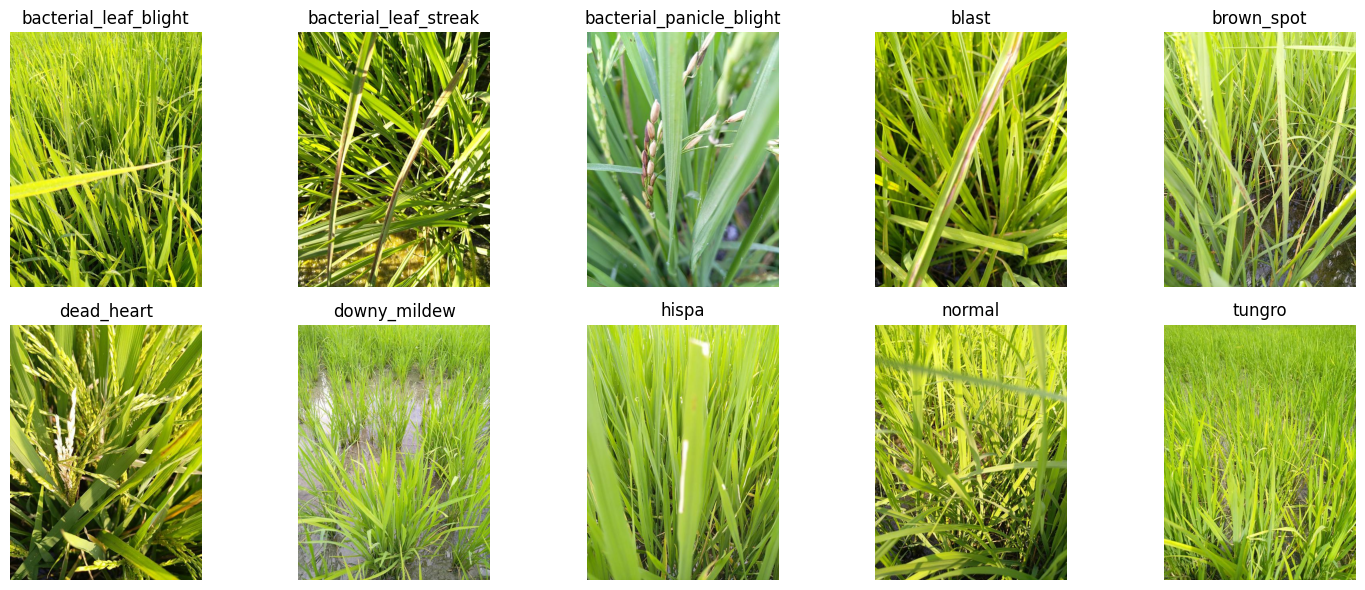

In [3]:
dataset_path = Path(kagglehub.competition_download('paddy-disease-classification'))
print('Path to competition files:', dataset_path)
print('Isi folder dataset:', sorted(os.listdir(dataset_path)))

train_csv_path = dataset_path / 'train.csv'
train_images_dir = dataset_path / 'train_images'
kaggle_test_images_dir = dataset_path / 'test_images'

assert train_csv_path.exists(), 'train.csv tidak ditemukan.'
assert train_images_dir.exists(), 'train_images tidak ditemukan.'
print('Catatan: test_images Kaggle tidak digunakan untuk evaluasi:', kaggle_test_images_dir.exists())

df = pd.read_csv(train_csv_path)
required_columns = {'image_id', 'label'}
assert required_columns.issubset(df.columns), f'Kolom wajib hilang: {required_columns - set(df.columns)}'

df['filepath'] = df.apply(lambda row: str(train_images_dir / row['label'] / row['image_id']), axis=1)
missing_files = df.loc[~df['filepath'].map(lambda file_path: Path(file_path).exists())]
assert missing_files.empty, f'Ada {len(missing_files)} file gambar yang tidak ditemukan.'

print('Contoh data:')
display(df.head())

label_counts = df['label'].value_counts().sort_index()
print('Jumlah total gambar:', len(df))
print('Jumlah kelas:', df['label'].nunique())
display(label_counts.rename('jumlah_gambar').to_frame())

sample_paths = df['filepath'].sample(n=min(1000, len(df)), random_state=SEED)
unique_sizes = {}
for file_path in sample_paths:
    with Image.open(file_path) as image:
        unique_sizes[image.size] = unique_sizes.get(image.size, 0) + 1

print('Jumlah resolusi unik pada sampel:', len(unique_sizes))
print('Contoh resolusi:', list(unique_sizes.keys())[:10])

sample_images = df.groupby('label', group_keys=False).sample(n=1, random_state=SEED)
cols = 5
rows = math.ceil(len(sample_images) / cols)
plt.figure(figsize=(15, 3 * rows))
for index, row in enumerate(sample_images.itertuples(index=False), start=1):
    plt.subplot(rows, cols, index)
    plt.imshow(Image.open(row.filepath).convert('RGB'))
    plt.title(row.label)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Data Preprocessing

Preprocessing menggunakan `ImageDataGenerator`. Augmentation hanya diterapkan pada train set, sedangkan validation dan test set hanya dinormalisasi dengan `rescale=1./255` agar evaluasi tetap objektif.

#### Split Dataset

Dataset berlabel dibagi menjadi train, validation, dan test dengan rasio 70:15:15. Split dilakukan secara stratified berdasarkan label.

In [4]:
class_names = sorted(df['label'].unique())

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

split_distribution = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'validation': val_df['label'].value_counts().sort_index(),
    'test': test_df['label'].value_counts().sort_index()
}).fillna(0).astype(int)
display(split_distribution)

assert not train_df['filepath'].str.contains('test_images').any(), 'Train set tidak boleh memakai test_images Kaggle.'
assert not val_df['filepath'].str.contains('test_images').any(), 'Validation set tidak boleh memakai test_images Kaggle.'
assert not test_df['filepath'].str.contains('test_images').any(), 'Test set tidak boleh memakai test_images Kaggle.'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

train_eval_generator = eval_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_generator.class_indices
index_to_label = {index: label for label, index in class_indices.items()}
class_names_by_index = [index_to_label[index] for index in range(len(index_to_label))]
print('class_indices:', class_indices)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {int(class_id): float(weight) for class_id, weight in zip(np.unique(train_generator.classes), weights)}
print('class_weights:', class_weights)

Train: 7284
Validation: 1561
Test: 1562


,train,validation,test
label,,,
bacterial_leaf_blight,335,72,72
bacterial_leaf_streak,266,57,57
bacterial_panicle_blight,236,51,50
blast,1216,261,261
brown_spot,675,145,145
dead_heart,1009,216,217
downy_mildew,434,93,93
hispa,1116,239,239
normal,1235,264,265


Found 7284 validated image filenames belonging to 10 classes.
Found 7284 validated image filenames belonging to 10 classes.
Found 1561 validated image filenames belonging to 10 classes.
Found 1562 validated image filenames belonging to 10 classes.
class_indices: {'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}
class_weights: {0: 2.1743283582089554, 1: 2.738345864661654, 2: 3.0864406779661016, 3: 0.5990131578947369, 4: 1.0791111111111111, 5: 0.7219028741328047, 6: 1.6783410138248849, 7: 0.6526881720430108, 8: 0.5897975708502025, 9: 0.9559055118110236}


## Modelling

Model dibuat menggunakan Keras `Sequential` dengan layer `Conv2D` dan `MaxPooling2D`. Training dijalankan dengan callback `EarlyStopping`, `ReduceLROnPlateau`, dan `ModelCheckpoint`.

In [5]:
num_classes = len(class_names_by_index)

model = Sequential([
    # Block 1 (150x150 -> 75x75)
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2 (75x75 -> 37x37)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 3 (37x37 -> 18x18)
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 4 (18x18 -> 9x9)
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 5 (9x9 -> 4x4)
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Head: GAP(512) -> Dense(256) -> Output
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
], name='paddy_disease_cnn')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

checkpoint_path = 'best_model.keras'
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

best_model = tf.keras.models.load_model(checkpoint_path)
print('Best checkpoint loaded from:', checkpoint_path)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "paddy_disease_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,493,226 (9.51 MB)

 Trainable params: 2,489,770 (9.50 MB)

 Non-trainable params: 3,456 (13.50 KB)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.1870 - loss: 2.8107
Epoch 1: val_accuracy improved from None to 0.15311, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 134s 432ms/step - accuracy: 0.2343 - loss: 2.5058 - val_accuracy: 0.1531 - val_loss: 5.4497 - learning_rate: 0.0010
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.3264 - loss: 2.0120
Epoch 2: val_accuracy improved from 0.15311 to 0.22422, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 66s 289ms/step - accuracy: 0.3482 - loss: 1.9327 - val_accuracy: 0.2242 - val_loss: 2.8485 - learning_rate: 0.0010
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.4031 - loss: 1.7067
Epoch 3: val_accuracy improved from 0.22422 to 0.46637, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━

## Evaluasi dan Visualisasi

Evaluasi dilakukan pada train set tanpa augmentation dan test set. Bagian ini menampilkan training accuracy, testing accuracy, classification report, confusion matrix, serta plot accuracy dan loss.

228/228 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.9462 - loss: 0.1599
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.9027 - loss: 0.3431
Training Accuracy: 0.9462 (94.62%)
Testing Accuracy: 0.9027 (90.27%)
Target akurasi minimal 85% terpenuhi.


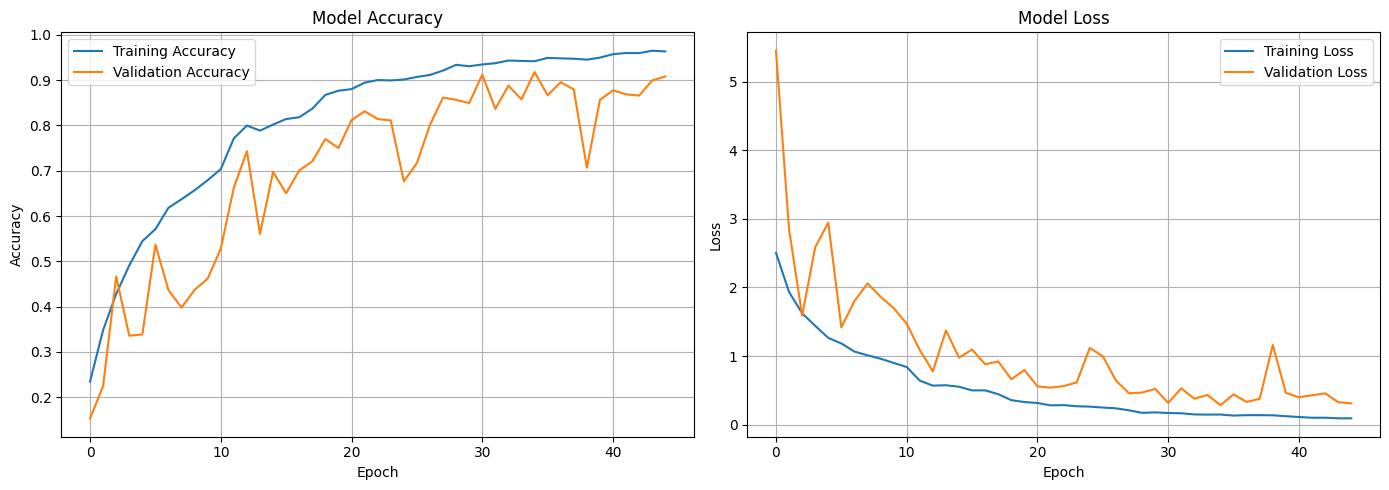

49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step
Classification Report:
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.87      0.92      0.89        72
   bacterial_leaf_streak       0.86      0.95      0.90        57
bacterial_panicle_blight       0.90      0.94      0.92        50
                   blast       0.89      0.93      0.91       261
              brown_spot       0.92      0.90      0.91       145
              dead_heart       0.96      0.96      0.96       217
            downy_mildew       0.78      0.77      0.78        93
                   hispa       0.93      0.82      0.87       239
                  normal       0.96      0.92      0.94       265
                  tungro       0.81      0.92      0.86       163

                accuracy                           0.90      1562
               macro avg       0.89      0.90      0.89      1562
            weighted avg       0.91      0.90      0.90      1562



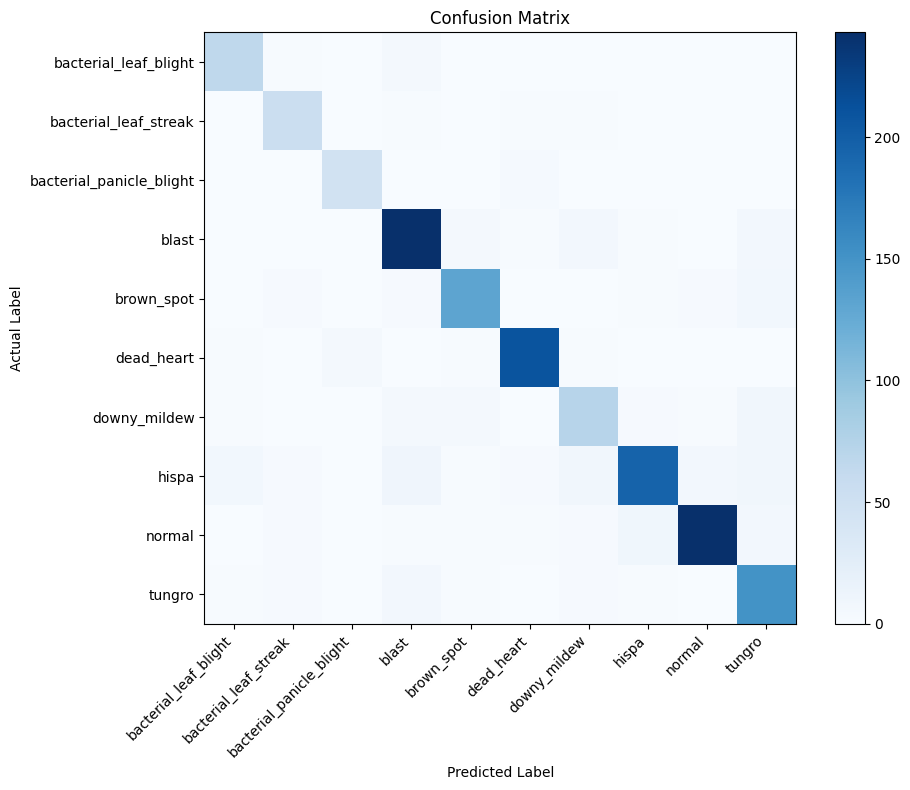

In [6]:
train_eval_generator.reset()
test_generator.reset()

train_loss, train_acc = best_model.evaluate(train_eval_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print(f'Training Accuracy: {train_acc:.4f} ({train_acc * 100:.2f}%)')
print(f'Testing Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)')

if train_acc >= TARGET_ACCURACY and test_acc >= TARGET_ACCURACY:
    print('Target akurasi minimal 85% terpenuhi.')
else:
    print('Target akurasi 85% belum terpenuhi pada run ini.')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

test_generator.reset()
pred_probabilities = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probabilities, axis=1)
y_true = test_generator.classes

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names_by_index))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names_by_index, rotation=45, ha='right')
plt.yticks(tick_marks, class_names_by_index)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Konversi Model

Model terbaik disimpan ke folder `submission/saved_model`, dikonversi ke TensorFlow Lite dan TensorFlow.js.

In [7]:
submission_dir = Path('submission')
saved_model_dir = submission_dir / 'saved_model'
tflite_dir = submission_dir / 'tflite'
tfjs_dir = submission_dir / 'tfjs_model'

submission_dir.mkdir(exist_ok=True)
for output_dir in [saved_model_dir, tflite_dir, tfjs_dir]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

# SavedModel
shutil.rmtree(saved_model_dir)
try:
    best_model.export(str(saved_model_dir))
except AttributeError:
    tf.saved_model.save(best_model, str(saved_model_dir))

assert (saved_model_dir / 'saved_model.pb').exists(), 'SavedModel gagal dibuat.'
assert (saved_model_dir / 'variables').exists(), 'Folder variables tidak ditemukan.'
print('SavedModel tersimpan di:', saved_model_dir)

# TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
tflite_model = converter.convert()
tflite_model_path = tflite_dir / 'model.tflite'
with open(tflite_model_path, 'wb') as file:
    file.write(tflite_model)

label_path = tflite_dir / 'label.txt'
with open(label_path, 'w', encoding='utf-8') as file:
    for label in class_names_by_index:
        file.write(label + '\n')

print('TFLite tersimpan di:', tflite_model_path)

# TensorFlow.js
if tfjs_dir.exists():
    shutil.rmtree(tfjs_dir)
tfjs_dir.mkdir(parents=True, exist_ok=True)

tfjs_converter = shutil.which('tensorflowjs_converter')
assert tfjs_converter is not None, 'tensorflowjs_converter tidak ditemukan.'

tfjs_command = [
    tfjs_converter,
    '--input_format=tf_saved_model',
    '--output_format=tfjs_graph_model',
    '--weight_shard_size_bytes=104857600',
    str(saved_model_dir),
    str(tfjs_dir)
]
subprocess.run(tfjs_command, check=True)
print('TFJS model tersimpan di:', tfjs_dir)

# Salin notebook
notebook_destination = submission_dir / 'notebook.ipynb'
if not notebook_destination.exists():
    copied_notebook = False
    for candidate in [Path('notebook.ipynb')]:
        if candidate.exists():
            shutil.copy(candidate, notebook_destination)
            copied_notebook = True
            break
    if not copied_notebook:
        try:
            from google.colab import _message
            notebook_payload = _message.blocking_request('get_ipynb', timeout_sec=10)
            with open(notebook_destination, 'w', encoding='utf-8') as file:
                json.dump(notebook_payload['ipynb'], file)
            copied_notebook = True
        except Exception as error:
            print('Notebook aktif belum bisa disalin otomatis:', error)
    if not copied_notebook:
        print('Simpan notebook ini sebagai submission/notebook.ipynb sebelum membuat zip final.')

# README dan requirements
readme_text = """# Smart Farming Rice Disease Detection Using CNN

Project klasifikasi gambar penyakit daun padi menggunakan CNN.
Dataset: Paddy Disease Classification dari Kaggle.

## Dataset Split
- Train: 70% | Validation: 15% | Test: 15%

## Output Model
- SavedModel: submission/saved_model
- TFLite: submission/tflite/model.tflite
- TFJS: submission/tfjs_model
"""

requirements_text = """tensorflow
tensorflowjs
numpy
pandas
matplotlib
scikit-learn
pillow
kagglehub
"""

with open(submission_dir / 'README.md', 'w', encoding='utf-8') as file:
    file.write(readme_text)
with open(submission_dir / 'requirements.txt', 'w', encoding='utf-8') as file:
    file.write(requirements_text)

expected_paths = [
    submission_dir / 'tfjs_model' / 'group1-shard1of1.bin',
    submission_dir / 'tfjs_model' / 'model.json',
    submission_dir / 'tflite' / 'model.tflite',
    submission_dir / 'tflite' / 'label.txt',
    submission_dir / 'saved_model' / 'saved_model.pb',
    submission_dir / 'saved_model' / 'variables',
    submission_dir / 'notebook.ipynb',
    submission_dir / 'README.md',
    submission_dir / 'requirements.txt'
]

missing_paths = [str(p) for p in expected_paths if not p.exists()]
assert not missing_paths, 'Struktur belum lengkap: ' + ', '.join(missing_paths)

def print_tree(root_path):
    root_path = Path(root_path)
    print(root_path.name)
    for current_root, dirs, files in os.walk(root_path):
        current_root = Path(current_root)
        dirs.sort()
        files.sort()
        level = len(current_root.relative_to(root_path).parts)
        indent = '    ' * level
        for d in dirs:
            print(f'{indent}|-- {d}')
        for f in files:
            print(f'{indent}|-- {f}')

print_tree(submission_dir)
archive_path = shutil.make_archive('submission', 'zip', 'submission')
print('Zip berhasil dibuat:', archive_path)

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137847671538128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137847671539280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137847671539088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137847671542160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137847671537744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137847671538896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137846226386384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137846226381584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137846226384272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137846226379856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13784622

## Inference menggunakan TF-Lite

Bagian ini melakukan inference menggunakan model TF-Lite yang telah diekspor, bukan model Keras di memory. Output berupa gambar, actual label, predicted label, dan confidence score.

TFLite Input Shape: [  1 150 150   3]
TFLite Input Dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


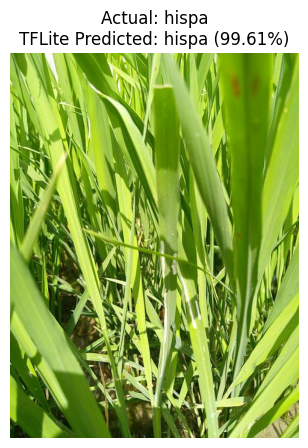

Actual Label    : hispa
TFLite Predicted: hispa
TFLite Confidence: 99.61%

--- Batch TF-Lite Inference (5 gambar) ---
  [OK] Actual: downy_mildew                   | Predicted: downy_mildew                   | Conf: 75.7%
  [OK] Actual: blast                          | Predicted: blast                          | Conf: 99.9%
  [OK] Actual: blast                          | Predicted: blast                          | Conf: 81.2%
  [OK] Actual: dead_heart                     | Predicted: dead_heart                     | Conf: 100.0%


In [ ]:
# -- Inference menggunakan TF-Lite --
tflite_model_path = str(submission_dir / 'tflite' / 'model.tflite')
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('TFLite Input Shape:', input_details[0]['shape'])
print('TFLite Input Dtype:', input_details[0]['dtype'])

# Ambil sample gambar dari test set
sample_row = test_df.sample(n=1, random_state=SEED).iloc[0]
image_path = sample_row['filepath']
actual_label = sample_row['label']

image = Image.open(image_path).convert('RGB')
resized_image = image.resize(IMG_SIZE)
image_array = tf.keras.utils.img_to_array(resized_image) / 255.0
image_array = np.expand_dims(image_array, axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], image_array)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])[0]

tflite_predicted_index = int(np.argmax(tflite_output))
tflite_predicted_label = class_names_by_index[tflite_predicted_index]
tflite_confidence = float(tflite_output[tflite_predicted_index])

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f'Actual: {actual_label}\nTFLite Predicted: {tflite_predicted_label} ({tflite_confidence * 100:.2f}%)')
plt.axis('off')
plt.show()

print(f'Actual Label    : {actual_label}')
print(f'TFLite Predicted: {tflite_predicted_label}')
print(f'TFLite Confidence: {tflite_confidence * 100:.2f}%')

# -- Batch inference 5 gambar --
print('\n--- Batch TF-Lite Inference (5 gambar) ---')
batch_samples = test_df.sample(n=5, random_state=SEED + 1)
correct = 0
for _, row in batch_samples.iterrows():
    img = Image.open(row['filepath']).convert('RGB').resize(IMG_SIZE)
    arr = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])[0]
    pred_label = class_names_by_index[int(np.argmax(out))]
    conf = float(out[int(np.argmax(out))])
    match = 'OK' if pred_label == row['label'] else 'MISS'
    if pred_label == row['label']:
        correct += 1
    print(f"  [{match}] Actual: {row['label']:30s} | Predicted: {pred_label:30s} | Conf: {conf*100:.1f}%")
print(f'  Batch accuracy: {correct}/{len(batch_samples)}')

# -- Buat ulang zip final --
notebook_destination = submission_dir / 'notebook.ipynb'
try:
    from google.colab import _message
    notebook_payload = _message.blocking_request('get_ipynb', timeout_sec=10)
    with open(notebook_destination, 'w', encoding='utf-8') as file:
        json.dump(notebook_payload['ipynb'], file)
except Exception as error:
    if notebook_destination.exists():
        print('\nMenggunakan notebook.ipynb yang sudah tersedia di folder submission.')
    else:
        print('Notebook aktif belum bisa disalin otomatis:', error)

missing_paths = [str(p) for p in expected_paths if not p.exists()]
assert not missing_paths, 'Struktur belum lengkap: ' + ', '.join(missing_paths)

print_tree(submission_dir)
archive_path = shutil.make_archive('submission', 'zip', 'submission')
print('Zip final berhasil dibuat:', archive_path)